# **Build Explainable Risk Prediction for Patient Readmission**

## Data Cleaning

In [16]:

import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\Admin\Documents\Projects\data\diabetic_data.csv", encoding='utf-8')
df.shape


(101766, 50)

In [18]:

null_percent = df.isnull().mean() * 100
print(null_percent[null_percent > 0].sort_values(ascending=False))

max_glu_serum    94.746772
A1Cresult        83.277322
dtype: float64


In [20]:
null_percent = df.isnull().mean() * 100
drop_cols = null_percent[null_percent > 70].index.tolist()
print("Silinəcək sütunlar:", drop_cols)
df = df.drop(columns=drop_cols)

Silinəcək sütunlar: ['max_glu_serum', 'A1Cresult']


In [22]:
df = df.drop(['encounter_id', 'patient_nbr'], axis=1)


df = df.drop(['weight'], axis=1)


df = df.drop(['payer_code', 'medical_specialty'], axis=1)

df.shape[1]

43

In [24]:
df.head(5)

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Target defining

In [26]:

df['target'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)
df = df.drop('readmitted', axis=1)


print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True).round(3))

target
0    90409
1    11357
Name: count, dtype: int64
target
0    0.888
1    0.112
Name: proportion, dtype: float64


In [30]:
#Imputing emeliyyatlari
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])


## Future Engineering

In [32]:
#df['total_visits'] = df['number_outpatient'] + df['number_emergency'] + df['number_inpatient']
#df['med_per_day'] = df['num_medications'] / (df['time_in_hospital'] + 1)
#df['lab_per_day'] = df['num_lab_procedures'] / (df['time_in_hospital'] + 1)
#df['repeat_admit'] = (df['number_inpatient'] > 1).astype(int)

#df.head(3)

## Encoding and Filling

In [37]:
age_map = {
    '[0-10)':5, '[10-20)':15, '[20-30)':25, '[30-40)':35, '[40-50)':45,
    '[50-60)':55, '[60-70)':65, '[70-80)':75, '[80-90)':85, '[90-100)':95
}
df['age'] = df['age'].map(age_map)

drug_cols = [
    'metformin','repaglinide','nateglinide','chlorpropamide',
    'glimepiride','acetohexamide','glipizide','glyburide',
    'tolbutamide','pioglitazone','rosiglitazone','acarbose',
    'miglitol','troglitazone','tolazamide','examide',
    'citoglipton','insulin','glyburide-metformin',
    'glipizide-metformin','glimepiride-pioglitazone',
    'metformin-rosiglitazone','metformin-pioglitazone','diabetesMed'
]


def map_drug(val):
    if val == 'No':
        return 0
    elif val in ['Steady', 'Yes']:
        return 1
    elif val == 'Up':
        return 2
    elif val == 'Down':
        return 3
    else:
        return np.nan

for col in drug_cols:
    if col in df.columns:
        df[col] = df[col].apply(map_drug)

# NaN-ları doldur
for col in drug_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

print(df[drug_cols[:3]].head())



   metformin  repaglinide  nateglinide
0          0            0            0
1          0            0            0
2          0            0            0
3          0            0            0
4          0            0            0


In [41]:
from sklearn.preprocessing import LabelEncoder
# Label Encoding — yalnız çox kateqoriyalılar 
label_encoders = {}
for col in ['diag_1', 'diag_2', 'diag_3']:
    enc = LabelEncoder()
    df[col] = enc.fit_transform(df[col].astype(str))
    label_encoders[col] = enc
# One-Hot 

df = pd.get_dummies(df,drop_first=True)



print("Cəmi sütun:", df.shape[1])

Cəmi sütun: 48


## Data Training

In [43]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, classification_report, 
                              confusion_matrix)
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

neg, pos = np.bincount(y_train)
spw = neg / pos
print(f"scale_pos_weight: {spw:.2f}")


scale_pos_weight: 7.96


## XGBoost Model AUC

In [45]:
from sklearn.metrics import (roc_auc_score, classification_report, 
                              confusion_matrix)
# Model
model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    scale_pos_weight=spw,
    eval_metric='auc',
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred,
      target_names=['Qayıtmadı', 'Qayıtdı']))

[0]	validation_0-auc:0.66306
[50]	validation_0-auc:0.68407
[100]	validation_0-auc:0.68643
[150]	validation_0-auc:0.68694
[200]	validation_0-auc:0.68779
[250]	validation_0-auc:0.68859
[300]	validation_0-auc:0.68852
[350]	validation_0-auc:0.68778
[400]	validation_0-auc:0.68749
[450]	validation_0-auc:0.68689
[499]	validation_0-auc:0.68633
AUC: 0.6863
              precision    recall  f1-score   support

   Qayıtmadı       0.93      0.70      0.80     18083
     Qayıtdı       0.19      0.57      0.28      2271

    accuracy                           0.68     20354
   macro avg       0.56      0.63      0.54     20354
weighted avg       0.85      0.68      0.74     20354



## **SHAP Model**

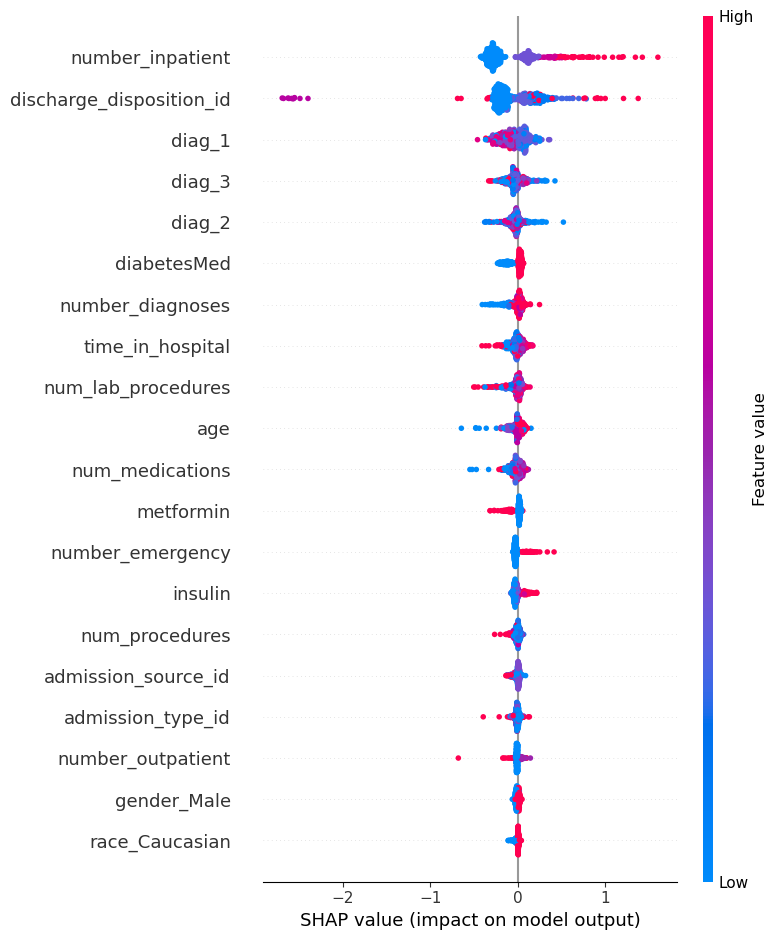

In [53]:
import shap

# SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test[:500])

# Global feature importance 
shap.summary_plot(shap_values, X_test[:500], 
                  feature_names=X_test.columns.tolist())


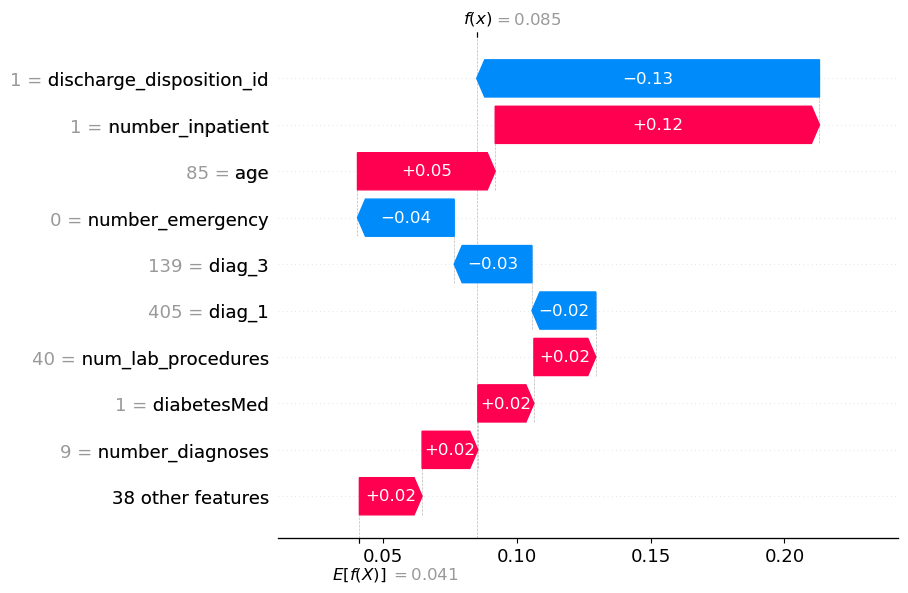

In [54]:
#tek xeste 
# 0-cı xəstəni izah et
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns.tolist()
    )
)


## **LIME Model**

In [58]:
import lime
import lime.lime_tabular

# LIME explainer
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['Qayıtmadı', 'Qayıtdı'],
    mode='classification'
)

# 0-cı xəstəni izah et
exp = explainer_lime.explain_instance(
    data_row=X_test.iloc[0].values,
    predict_fn=model.predict_proba,
    num_features=10
)

exp.show_in_notebook()

## TOP xesteler ve PDF (bonus)

In [61]:
# Bütün xəstələr üçün risk ehtimalı
X_test_copy = X_test.copy()
X_test_copy['risk_prob'] = model.predict_proba(X_test)[:, 1]
X_test_copy['actual'] = y_test.values

# top 10 xəstə
top10 = X_test_copy.nlargest(10, 'risk_prob')[['risk_prob', 'actual']]
print(top10)

        risk_prob  actual
94885    0.939373       1
62759    0.934560       1
101629   0.930288       1
25881    0.929403       1
88392    0.925144       0
92991    0.922848       1
26412    0.915427       1
97732    0.915192       0
79436    0.913794       0
52200    0.913552       0


In [63]:
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle
from reportlab.lib.styles import getSampleStyleSheet
from datetime import datetime

def generate_report(patient_idx, probability, lime_exp):
    path = f'patient_{patient_idx}_report.pdf'
    doc = SimpleDocTemplate(path, pagesize=A4)
    styles = getSampleStyleSheet()
    story = []

    # Başlıq
    story.append(Paragraph('Xəstə Yenidən Qəbul Riski Hesabatı', styles['Title']))
    story.append(Spacer(1, 12))

    # Risk səviyyəsi
    level = 'YÜKSƏK RİSK' if probability >= 0.45 else 'AŞAĞI RİSK'
    story.append(Paragraph(f'Risk Ehtimalı: {probability:.1%} — {level}', styles['Heading2']))
    story.append(Spacer(1, 12))

    # LIME qaydaları
    story.append(Paragraph('LIME İzahı:', styles['Heading3']))
    for rule, val in lime_exp.as_list():
        color = '🔴' if val > 0 else '🔵'
        story.append(Paragraph(f'{color} {rule} → {val:.3f}', styles['Normal']))

    # Tarix
    story.append(Spacer(1, 20))
    story.append(Paragraph(f'Tarix: {datetime.now().strftime("%Y-%m-%d %H:%M")}', styles['Normal']))

    doc.build(story)
    print(f'PDF → {path}')

# 0-cı xəstə üçün report yarat
prob = model.predict_proba(X_test.iloc[[0]])[0, 1]
exp = explainer_lime.explain_instance(
    data_row=X_test.iloc[0].values,
    predict_fn=model.predict_proba,
    num_features=10
)
generate_report(0, prob, exp)

PDF → patient_0_report.pdf
